In [1]:
# ============================================================
# CELL 1: CONFIG + LOAD MODELS
# ============================================================
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = "Medicinal Plant Leaf Health Split Dataset"
CHECKPOINTS_DIR = "checkpoints"
IMG_SIZE = 128

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
test_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), transform=eval_tf)
class_names = test_ds.classes
NUM_CLASSES = len(class_names)

# --- custom CNN architecture ---
class LightCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.3), nn.Linear(128, num_classes))

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)

def build_model(name, num_classes):
    if name == "mobilenet_v3_small":
        m = models.mobilenet_v3_small(weights=None)
        m.classifier[3] = nn.Linear(m.classifier[3].in_features, num_classes)
    elif name == "shufflenet_v2":
        m = models.shufflenet_v2_x1_0(weights=None)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
    elif name == "efficientnet_b0":
        m = models.efficientnet_b0(weights=None)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
    elif name == "custom_cnn":
        m = LightCNN(num_classes)
    else:
        raise ValueError(f"Unknown model: {name}")
    return m

# Load LightCNN
lightcnn = build_model("custom_cnn", NUM_CLASSES).to(DEVICE)
lightcnn.load_state_dict(torch.load(os.path.join(CHECKPOINTS_DIR, "custom_cnn_full", "best_model.pth"), map_location=DEVICE))
lightcnn.eval()

# Load EfficientNet-B0
effnet = build_model("efficientnet_b0", NUM_CLASSES).to(DEVICE)
effnet.load_state_dict(torch.load(os.path.join(CHECKPOINTS_DIR, "efficientnet_b0_full", "best_model.pth"), map_location=DEVICE))
effnet.eval()

# Load ensemble components
ENSEMBLE_CANDIDATES = [
    {"name": "efficientnet_b0", "run_tag": "efficientnet_b0_full"},
    {"name": "shufflenet_v2",   "run_tag": "shufflenet_v2_full"},
    {"name": "shufflenet_v2",   "run_tag": "shufflenet_v2_partial"},
    {"name": "mobilenet_v3_small", "run_tag": "mobilenet_v3_small_full"},
]
ensemble_models = []
for c in ENSEMBLE_CANDIDATES:
    m = build_model(c["name"], NUM_CLASSES).to(DEVICE)
    m.load_state_dict(torch.load(os.path.join(CHECKPOINTS_DIR, c["run_tag"], "best_model.pth"), map_location=DEVICE))
    m.eval()
    ensemble_models.append(m)

print("All models loaded.")

/tmp/ipykernel_14587/1248967937.py:62: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  lightcnn.load_state_dict(torch.load(os.path.join(CHECKPOINTS_DIR, "custom_cnn_full", "be

All models loaded.


Selected: Aloe Vera Young Healthy -> Medicinal Plant Leaf Health Split Dataset/test/Aloe Vera Young Healthy/IMG20260204135303.png
Selected: Aloe Vera Disease -> Medicinal Plant Leaf Health Split Dataset/test/Aloe Vera Disease/IMG20260204141552.png
Selected: Kalanchoe Pinnata Disease -> Medicinal Plant Leaf Health Split Dataset/test/Kalanchoe Pinnata Disease/IMG20260227135710.png
Selected: Azadirachta Indica Chlorotic -> Medicinal Plant Leaf Health Split Dataset/test/Azadirachta Indica Chlorotic/IMG20260107135607.png


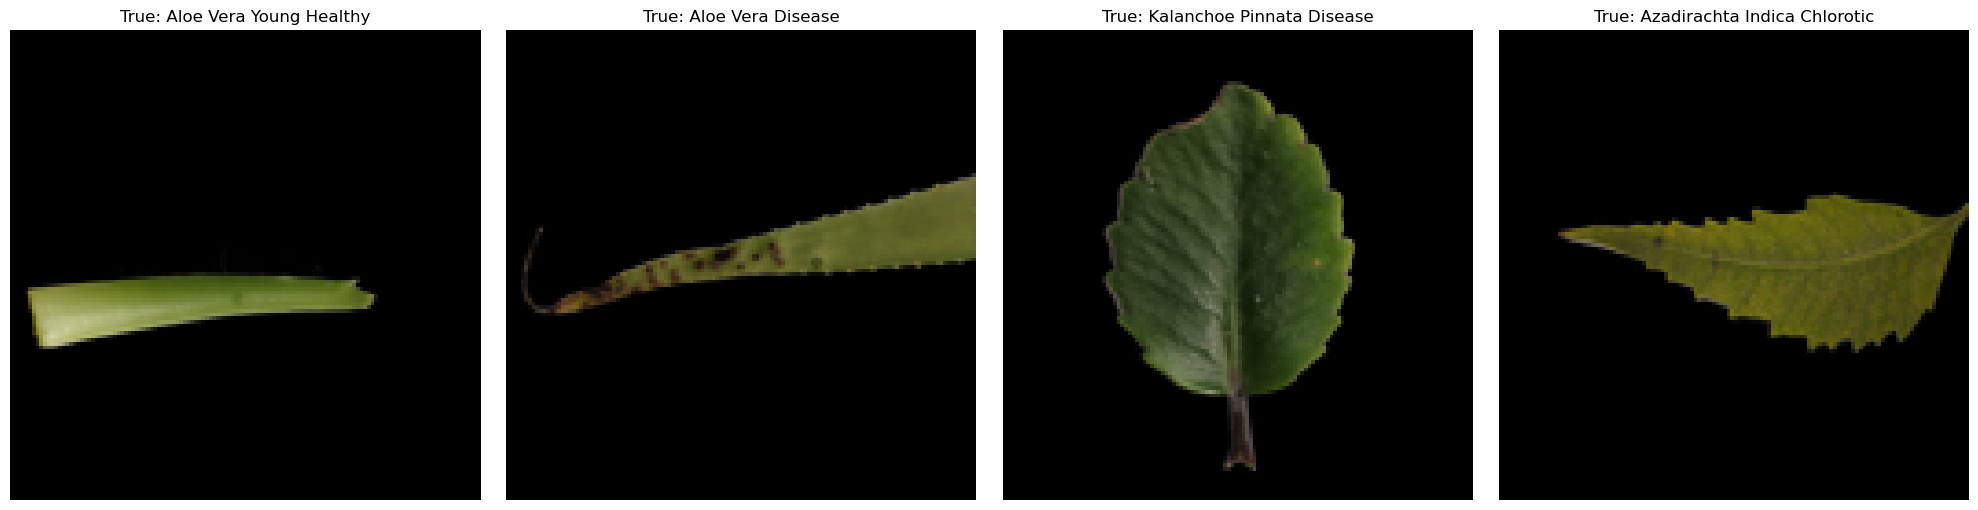

In [2]:
# ============================================================
# CELL 2 (UPDATED): PICK 4+ TEST IMAGES FROM DIFFERENT CLASSES
# ============================================================
import random
random.seed(42)

N_IMAGES = 4  # increase if you want more

# group test samples by class, pick one image per distinct class
samples_by_class = {}
for path, label_idx in test_ds.samples:
    cls = class_names[label_idx]
    if cls not in samples_by_class:
        samples_by_class[cls] = []
    samples_by_class[cls].append(path)

# randomly select N_IMAGES distinct classes
selected_classes = random.sample(list(samples_by_class.keys()), N_IMAGES)

selected_images = []
for cls in selected_classes:
    img_path = random.choice(samples_by_class[cls])
    true_label_idx = class_names.index(cls)
    selected_images.append((img_path, true_label_idx, cls))
    print(f"Selected: {cls} -> {img_path}")

# preview all selected images
fig, axes = plt.subplots(1, N_IMAGES, figsize=(5 * N_IMAGES, 5))
for i, (img_path, _, cls) in enumerate(selected_images):
    pil_img = Image.open(img_path).convert("RGB")
    axes[i].imshow(pil_img.resize((IMG_SIZE, IMG_SIZE)))
    axes[i].set_title(f"True: {cls}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

In [3]:
# ============================================================
# CELL 3-8 WRAPPED INTO ONE LOOP — RUN GRAD-CAM + LIME FOR EACH IMAGE
# ============================================================
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from lime import lime_image
from skimage.segmentation import mark_boundaries

def get_target_layer(model, arch_name):
    if arch_name == "efficientnet_b0":
        return model.features[-1]
    elif arch_name == "shufflenet_v2":
        return model.conv5
    elif arch_name == "mobilenet_v3_small":
        return model.features[-1]
    else:
        raise ValueError(arch_name)

def run_gradcam(model, target_layer, input_tensor, rgb_img):
    cam = GradCAM(model=model, target_layers=[target_layer])
    grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0]
    with torch.no_grad():
        output = model(input_tensor)
        pred_idx = output.argmax(dim=1).item()
    return grayscale_cam, class_names[pred_idx]

def predict_fn_factory(model):
    def predict_fn(images):
        batch = []
        for img in images:
            pil = Image.fromarray(img.astype("uint8"))
            tensor = eval_tf(pil)
            batch.append(tensor)
        batch = torch.stack(batch).to(DEVICE)
        with torch.no_grad():
            outputs = model(batch)
            probs = F.softmax(outputs, dim=1).cpu().numpy()
        return probs
    return predict_fn

def ensemble_predict_fn(images):
    batch = []
    for img in images:
        pil = Image.fromarray(img.astype("uint8"))
        tensor = eval_tf(pil)
        batch.append(tensor)
    batch = torch.stack(batch).to(DEVICE)
    with torch.no_grad():
        probs_sum = None
        for model in ensemble_models:
            outputs = model(batch)
            probs = F.softmax(outputs, dim=1)
            probs_sum = probs if probs_sum is None else probs_sum + probs
        avg_probs = (probs_sum / len(ensemble_models)).cpu().numpy()
    return avg_probs

def run_lime(predict_fn, rgb_img_255, num_samples=1000):
    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(
        rgb_img_255.astype("double"), predict_fn,
        top_labels=1, hide_color=0, num_samples=num_samples
    )
    top_label = explanation.top_labels[0]
    temp, mask = explanation.get_image_and_mask(top_label, positive_only=True, num_features=5, hide_rest=False)
    return mask, class_names[top_label]

# ---- storage for all results ----
all_gradcam_results = []
all_lime_results = []

lightcnn_target_layer = lightcnn.features[-3]
effnet_target_layer = effnet.features[-1]

for img_path, true_label_idx, true_class in selected_images:
    print(f"\nProcessing: {true_class} ({img_path})")

    pil_img = Image.open(img_path).convert("RGB")
    input_tensor = eval_tf(pil_img).unsqueeze(0).to(DEVICE)
    rgb_img = np.array(pil_img.resize((IMG_SIZE, IMG_SIZE))) / 255.0
    rgb_img_255 = (rgb_img * 255).astype("uint8")

    # --- Grad-CAM: LightCNN, EfficientNet-B0, Ensemble ---
    cam_light, pred_light = run_gradcam(lightcnn, lightcnn_target_layer, input_tensor, rgb_img)
    cam_eff, pred_eff = run_gradcam(effnet, effnet_target_layer, input_tensor, rgb_img)

    ensemble_cams = []
    for model, c in zip(ensemble_models, ENSEMBLE_CANDIDATES):
        target_layer = get_target_layer(model, c["name"])
        cam = GradCAM(model=model, target_layers=[target_layer])
        ensemble_cams.append(cam(input_tensor=input_tensor, targets=None)[0])
    cam_ens = np.mean(ensemble_cams, axis=0)

    with torch.no_grad():
        probs_sum = None
        for model in ensemble_models:
            outputs = model(input_tensor)
            probs = F.softmax(outputs, dim=1)
            probs_sum = probs if probs_sum is None else probs_sum + probs
        pred_ens = class_names[(probs_sum / len(ensemble_models)).argmax(dim=1).item()]

    all_gradcam_results.append({
        "true_class": true_class, "rgb_img": rgb_img,
        "cam_light": cam_light, "pred_light": pred_light,
        "cam_eff": cam_eff, "pred_eff": pred_eff,
        "cam_ens": cam_ens, "pred_ens": pred_ens,
    })

    # --- LIME: LightCNN, EfficientNet-B0, Ensemble ---
    mask_light, lime_pred_light = run_lime(predict_fn_factory(lightcnn), rgb_img_255)
    mask_eff, lime_pred_eff = run_lime(predict_fn_factory(effnet), rgb_img_255)
    mask_ens, lime_pred_ens = run_lime(ensemble_predict_fn, rgb_img_255)

    all_lime_results.append({
        "true_class": true_class, "rgb_img_255": rgb_img_255,
        "mask_light": mask_light, "lime_pred_light": lime_pred_light,
        "mask_eff": mask_eff, "lime_pred_eff": lime_pred_eff,
        "mask_ens": mask_ens, "lime_pred_ens": lime_pred_ens,
    })

print("\nDone processing all images.")


Processing: Aloe Vera Young Healthy (Medicinal Plant Leaf Health Split Dataset/test/Aloe Vera Young Healthy/IMG20260204135303.png)


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]


Processing: Aloe Vera Disease (Medicinal Plant Leaf Health Split Dataset/test/Aloe Vera Disease/IMG20260204141552.png)


...


Processing: Azadirachta Indica Chlorotic (Medicinal Plant Leaf Health Split Dataset/test/Azadirachta Indica Chlorotic/IMG20260107135607.png)


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]


Done processing all images.


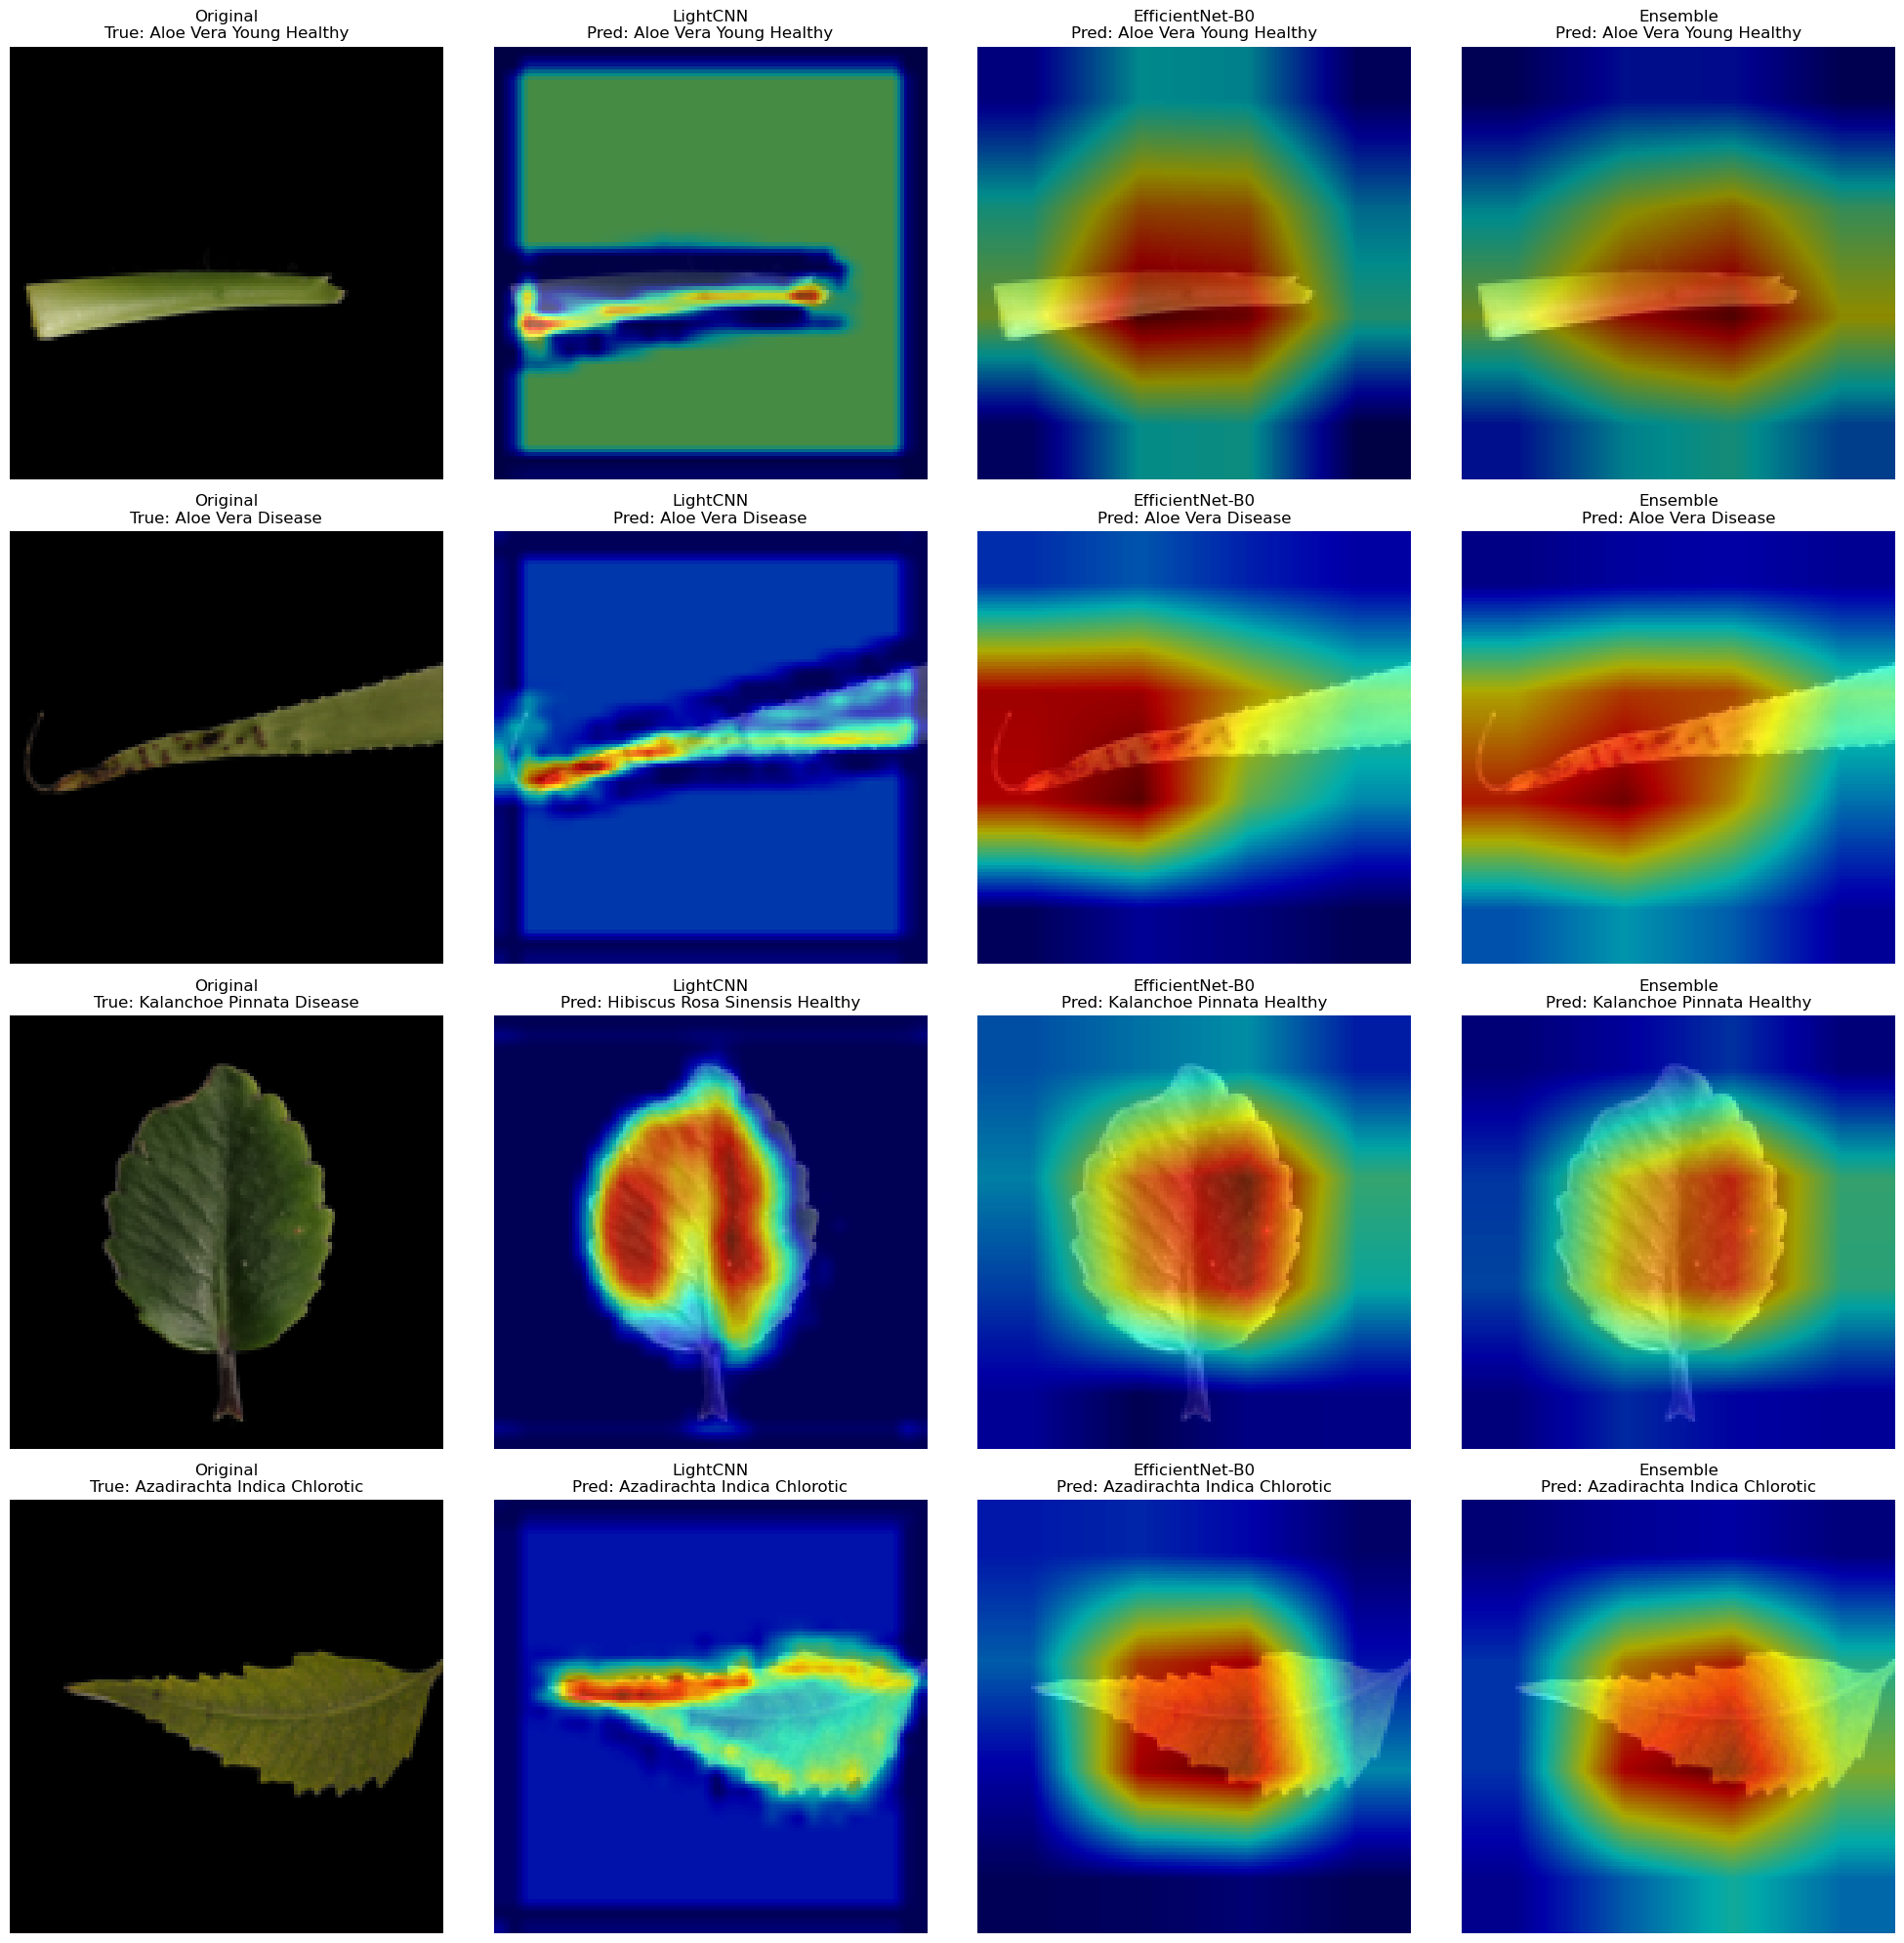

In [4]:
# ============================================================
# CELL 9: GRID VISUALIZATION — ALL IMAGES x ALL MODELS (GRAD-CAM)
# ============================================================
n_rows = len(all_gradcam_results)
fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5 * n_rows))

for row_idx, res in enumerate(all_gradcam_results):
    axes[row_idx, 0].imshow(res["rgb_img"])
    axes[row_idx, 0].set_title(f"Original\nTrue: {res['true_class']}")
    axes[row_idx, 0].axis("off")

    vis_light = show_cam_on_image(res["rgb_img"].astype(np.float32), res["cam_light"], use_rgb=True)
    axes[row_idx, 1].imshow(vis_light)
    axes[row_idx, 1].set_title(f"LightCNN\nPred: {res['pred_light']}")
    axes[row_idx, 1].axis("off")

    vis_eff = show_cam_on_image(res["rgb_img"].astype(np.float32), res["cam_eff"], use_rgb=True)
    axes[row_idx, 2].imshow(vis_eff)
    axes[row_idx, 2].set_title(f"EfficientNet-B0\nPred: {res['pred_eff']}")
    axes[row_idx, 2].axis("off")

    vis_ens = show_cam_on_image(res["rgb_img"].astype(np.float32), res["cam_ens"], use_rgb=True)
    axes[row_idx, 3].imshow(vis_ens)
    axes[row_idx, 3].set_title(f"Ensemble\nPred: {res['pred_ens']}")
    axes[row_idx, 3].axis("off")

plt.tight_layout()
plt.savefig("gradcam_grid_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

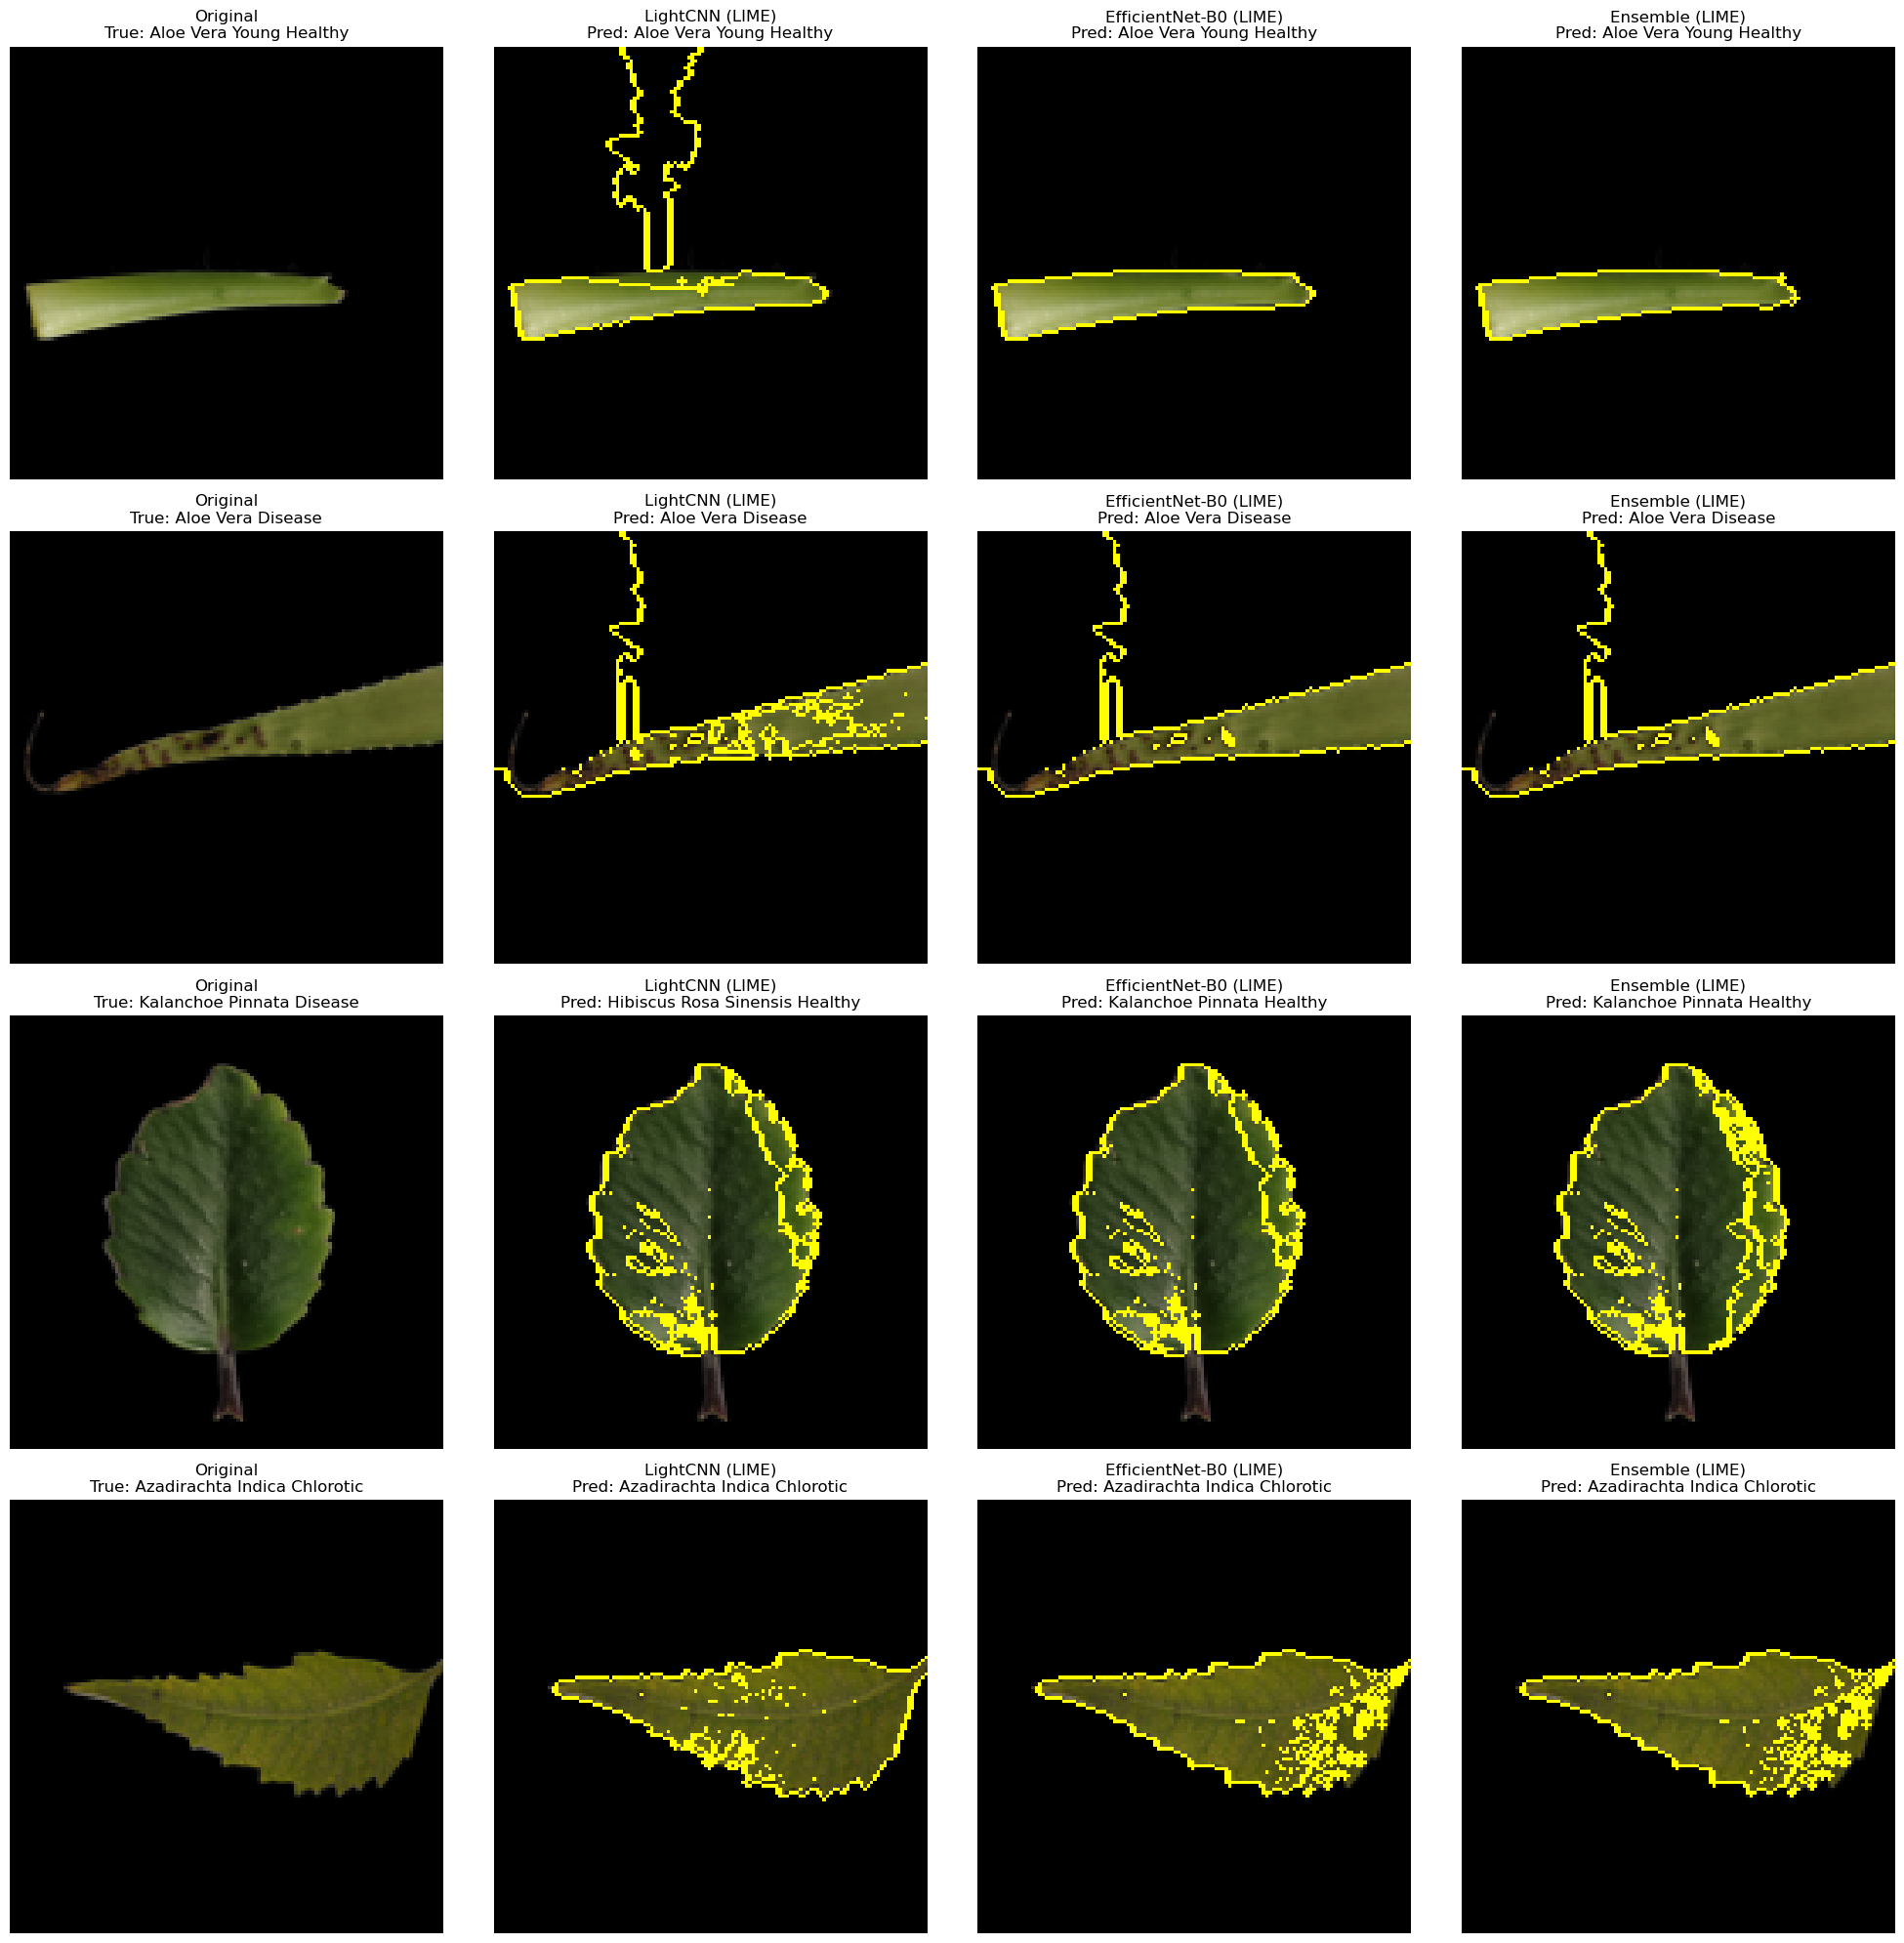

In [5]:
# ============================================================
# CELL 10: GRID VISUALIZATION — ALL IMAGES x ALL MODELS (LIME)
# ============================================================
n_rows = len(all_lime_results)
fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5 * n_rows))

for row_idx, res in enumerate(all_lime_results):
    axes[row_idx, 0].imshow(res["rgb_img_255"])
    axes[row_idx, 0].set_title(f"Original\nTrue: {res['true_class']}")
    axes[row_idx, 0].axis("off")

    axes[row_idx, 1].imshow(mark_boundaries(res["rgb_img_255"] / 255.0, res["mask_light"]))
    axes[row_idx, 1].set_title(f"LightCNN (LIME)\nPred: {res['lime_pred_light']}")
    axes[row_idx, 1].axis("off")

    axes[row_idx, 2].imshow(mark_boundaries(res["rgb_img_255"] / 255.0, res["mask_eff"]))
    axes[row_idx, 2].set_title(f"EfficientNet-B0 (LIME)\nPred: {res['lime_pred_eff']}")
    axes[row_idx, 2].axis("off")

    axes[row_idx, 3].imshow(mark_boundaries(res["rgb_img_255"] / 255.0, res["mask_ens"]))
    axes[row_idx, 3].set_title(f"Ensemble (LIME)\nPred: {res['lime_pred_ens']}")
    axes[row_idx, 3].axis("off")

plt.tight_layout()
plt.savefig("lime_grid_comparison.png", dpi=300, bbox_inches="tight")
plt.show()